### hypothesis function: $$\hat{y} = h_\theta (x) = \theta x$$

## MSE: cost function $$MSE(X, h_\theta) = \frac{1}{m} \sum_{i=1}^{m}(\theta^Tx^{(i)} - y^{(i)})^2$$

### Creating features and labels

In [1]:
import numpy as np

X = 3 * np.random.rand(100, 1)
y = 3 + 2 * X + np.random.randn(100, 1)  # a affine function with noise

### The variable y equation above can be translated to: $$y = \theta_0 + \theta_1 X + noise$$
### y only has one **weight** ($\theta_1$) because X only has one **feature** ($x_1$)

## Normal Equation $$\hat{\theta} = (X^TX)^{-1}X^Ty$$

In [2]:
X_b = np.c_[np.ones((100, 1)), X]  # add x0 = 1 in every instance, to multiply the intercept  
theta_best = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y) # normal equation
theta_best

array([[2.9377129],
       [1.9609926]])

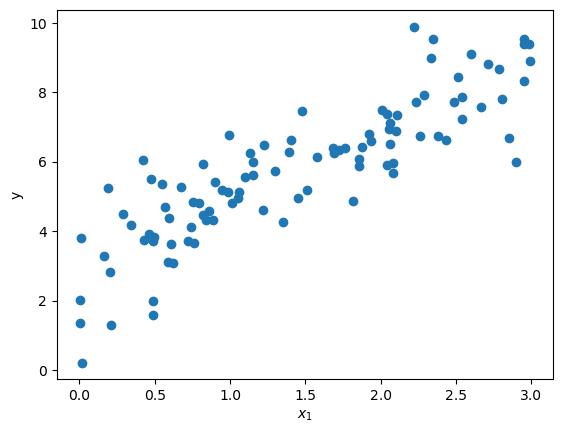

In [3]:
import matplotlib.pyplot as plt

plt.scatter(X, y)
plt.ylabel("y")
plt.xlabel("$x_1$")
plt.show()

In [4]:
X_new = np.array([[0], [2]])
X_new_b = np.c_[np.ones((2, 1)), X_new] # add x0 = 1 for each instance
y_predict = X_new_b.dot(theta_best)
y_predict

array([[2.9377129],
       [6.8596981]])

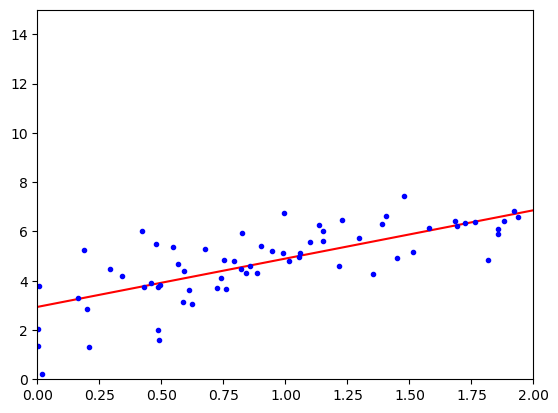

In [5]:
plt.plot(X_new, y_predict, "r-")
plt.plot(X, y, "b.")
plt.axis([0, 2, 0, 15])
plt.show()

In [6]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X, y)
lin_reg.intercept_, lin_reg.coef_  # Same result as theta_best

(array([2.9377129]), array([[1.9609926]]))

In [7]:
lin_reg.predict(X_new) # Same result as 'X_new_b.dot(theta_best)'

array([[2.9377129],
       [6.8596981]])

In [8]:
theta_best_svd, residuals, rank, s = np.linalg.lstsq(X_b, y, rcond=1e-6) # Same funcionality as LinearRegression
theta_best_svd

array([[2.9377129],
       [1.9609926]])

### The function below calculates $\hat{\theta} = X^+y$ where $X^+$ is the pseudo-inverse of $X$:

In [9]:
np.linalg.pinv(X_b).dot(y) # Same result as normal equation...

array([[2.9377129],
       [1.9609926]])

### MSE cost function gradient vector (Batch Gradient Descent): $$\nabla_\theta \text{MSE}(\theta) = \begin{bmatrix} \frac{\partial J}{\partial \theta_0} \ \frac{\partial J}{\partial \theta_1} \ \vdots \ \frac{\partial J}{\partial \theta_n} \end{bmatrix} = \frac{2}{m}X^T(X\theta - y)$$ 

### Compute the cost function gradient learning: $$\theta(\text{next step}) = \theta - \eta \nabla_\theta \text{MSE}(\theta)$$
#### $\eta$ -> learning rate

In [10]:
eta = 0.001 # learning rate 
n_iterations = 1000
m = 100

theta = np.random.randn(2, 1) # a 'random initialization' in model parameters

for i in range(n_iterations):
    gradients = 2/m * X_b.T.dot(X_b.dot(theta) - y) # gradient vector
    theta = theta - eta * gradients

theta # The result: trying to predict the features weights

array([[0.72488758],
       [3.17058738]])

### The learning rate above was so tiny. Now it learning rate is going TO COOK!

In [16]:
eta = 0.1 
n_iterations = 1000
m = 100

theta = np.random.randn(2, 1) 

for i in range(n_iterations):
    gradients = 2/m * X_b.T.dot(X_b.dot(theta) - y) 
    theta = theta - eta * gradients

theta # The result: a perfect prediction

array([[2.9377129],
       [1.9609926]])

### Stochastic Gradient Descent (SGD) 